# **Bank Churn Prediction**


**Business Context**

Businesses like banks that provide service have to worry about the problem of 'Churn' i.e. customers leaving and joining another service provider. It is important to understand which aspects of the service influence a customer's decision in this regard. Management can concentrate efforts on the improvement of service, keeping in mind these priorities.

**Objective**

Given a Bank customer, build aneural network-based classifier that can determine whether they will leave or not in the next 6 months.

**Data Description**

The case study is from an open-source dataset from Kaggle. The dataset contains 10,000 sample points with 14 distinct features such as CustomerId, CreditScore, Geography, Gender, Age, Tenure, Balance, etc.

**Data Dictionary**

**CustomerId:** Unique ID which is assigned to each customer

**Surname:** Last name of the customer

**CreditScore:** It defines the credit history of the customer.

**Geography:** A customer’s location

**Gender:** It defines the Gender of the customer

**Age:** Age of the customer

**Tenure:** Number of years for which the customer has been with the bank

**NumOfProducts:** It refers to the number of products that a customer has purchased through the bank.

**Balance:** Account balance

**HasCrCard:** It is a categorical variable that decides whether the customer has a credit card or not.

**EstimatedSalary:** Estimated salary

**isActiveMember:** It is a categorical variable that decides whether the customer is an active member of the bank or not ( Active member in the sense, using bank products regularly, making transactions, etc )

**Exited:** It is a categorical variable that decides whether the customer left the bank within six months or not. It can take two values
0=No ( Customer did not leave the bank )
1=Yes ( Customer left the bank )



## **Imports and Data Loading**

In [241]:
# Importing necessary library.

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")
%matplotlib inline
pd.set_option("display.max_columns", None)

In [242]:
# Reading the CSV file.
data = pd.read_csv("bank-1.csv")

In [243]:
# Making the copy of original data for further analysis.
df = data.copy()

In [244]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## **Basic Data Understanding**

In [245]:
# Checking the shape of the dataset.
df.shape

(10000, 14)

In [246]:
# Checking the dataset info.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


**Observations:**

The dataset contains 10,000 records and 14 features, indicating a reasonably large dataset suitable for training a neural network.

No missing values are present in any column, so no imputation is required.

The dataset consists of:

9 numerical (int64) features

2 continuous (float64) features

3 categorical (object) features

Columns like RowNumber and CustomerId are unique identifiers and do not contribute to predictive modeling.

Surname is a high-cardinality categorical variable and is unlikely to add meaningful predictive value.

***Fixing the data types***

In [247]:
# Columns that are categorical by nature (even if numeric)
categorical_cols = [
    'Geography',
    'Gender',
    'NumOfProducts',
    'HasCrCard',
    'IsActiveMember',
    'Exited'
]

# Identifier columns (to be excluded later from modeling)
id_cols = ['RowNumber', 'CustomerId', 'Surname']

# Truly numerical columns
numerical_cols = [
    'CreditScore',
    'Age',
    'Tenure',
    'Balance',
    'EstimatedSalary'
]

# Convert categorical columns to category dtype
df[categorical_cols] = df[categorical_cols].astype('category')

# Convert numerical columns to numeric
df[numerical_cols] = df[numerical_cols].apply(pd.to_numeric)

# Optional: convert ID columns to object (or leave as is)
df[id_cols] = df[id_cols].astype('object')

# Check final data types
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   RowNumber        10000 non-null  object  
 1   CustomerId       10000 non-null  object  
 2   Surname          10000 non-null  object  
 3   CreditScore      10000 non-null  int64   
 4   Geography        10000 non-null  category
 5   Gender           10000 non-null  category
 6   Age              10000 non-null  int64   
 7   Tenure           10000 non-null  int64   
 8   Balance          10000 non-null  float64 
 9   NumOfProducts    10000 non-null  category
 10  HasCrCard        10000 non-null  category
 11  IsActiveMember   10000 non-null  category
 12  EstimatedSalary  10000 non-null  float64 
 13  Exited           10000 non-null  category
dtypes: category(6), float64(2), int64(3), object(3)
memory usage: 684.5+ KB


In [248]:
# Checking the summary of categorical columns of the dataset.
df.describe(include=["category"]).T

,count,unique,top,freq
Geography,10000,3,France,5014
Gender,10000,2,Male,5457
NumOfProducts,10000,4,1,5084
HasCrCard,10000,2,1,7055
IsActiveMember,10000,2,1,5151
Exited,10000,2,0,7963


**Observations:**

**Geography**: The majority of customers belong to France (≈50%), indicating a strong regional concentration in the customer base.

**Gender**: The dataset has a slightly higher proportion of male customers, though the distribution is fairly balanced.

**NumOfProducts**: Most customers hold only one product, suggesting limited product penetration and potential for cross-selling.

**HasCrCard**: A large majority of customers possess a credit card, indicating high adoption of basic banking products.

**IsActiveMember**: Customer activity levels are almost evenly split, highlighting a significant segment that may require engagement initiatives.

**Exited**: Around 80% of customers have not exited, confirming that the dataset is imbalanced and churn is a minority class.

In [249]:
# Checking the statistical summary numerical columns of the dataset.
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CreditScore,10000.0,650.528800,96.653299,350.00,584.00,652.000,718.0000,850.00
Age,10000.0,38.921800,10.487806,18.00,32.00,37.000,44.0000,92.00
Tenure,10000.0,5.012800,2.892174,0.00,3.00,5.000,7.0000,10.00
Balance,10000.0,76485.889288,62397.405202,0.00,0.00,97198.540,127644.2400,250898.09
EstimatedSalary,10000.0,100090.239881,57510.492818,11.58,51002.11,100193.915,149388.2475,199992.48


**Observations:**

**CreditScore**: The average credit score is around 650, indicating a moderately creditworthy customer base with a wide range of financial reliability.

**Age**: Customers are primarily middle-aged, with most falling between 32 and 44 years, while older customers extend up to 92 years, suggesting age-driven churn risk.

**Tenure**: The average tenure is approximately 5 years, indicating a balanced mix of new and long-term customers.

**Balance**: Nearly 25% of customers maintain a zero balance, while active accounts show high variability, highlighting different engagement and usage patterns.

**EstimatedSalary**: Customer salaries are widely distributed with a mean close to ₹100K, suggesting income alone may not be a strong churn indicator.

In [250]:
# Checking the missing values in the dataset
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


**Observation**:

There is no missing vlaue in the dataset.

In [251]:
# Dropping the column which is not adding any information.
# Columns like RowNumber and CustomerId are unique identifiers and do not contribute to predictive modeling.
# Surname is a high-cardinality categorical variable and is unlikely to add meaningful predictive value.

df.drop(["RowNumber", "CustomerId", "Surname"], axis = 1, inplace=True)

In [252]:
# Let's look at the unique values of all the categories.
cols_cat= df.select_dtypes(["category"])

for i in cols_cat.columns:
    print('Unique values in',i, 'are :')
    print(cols_cat[i].value_counts())
    print('*'*50)

Unique values in Geography are :
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64
**************************************************
Unique values in Gender are :
Gender
Male      5457
Female    4543
Name: count, dtype: int64
**************************************************
Unique values in NumOfProducts are :
NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64
**************************************************
Unique values in HasCrCard are :
HasCrCard
1    7055
0    2945
Name: count, dtype: int64
**************************************************
Unique values in IsActiveMember are :
IsActiveMember
1    5151
0    4849
Name: count, dtype: int64
**************************************************
Unique values in Exited are :
Exited
0    7963
1    2037
Name: count, dtype: int64
**************************************************


**Observations:**

**Geography**: France contributes to nearly half of the customer base, while Germany and Spain have a similar share, enabling region-specific churn analysis.

**Gender**: The customer base is fairly balanced between males and females, with a slight dominance of male customers.

**NumOfProducts**: Most customers hold one or two products, while customers with three or four products form a very small segment, indicating limited multi-product adoption.

**HasCrCard**: A significant majority of customers own a credit card, suggesting credit card ownership alone is not a strong differentiator for churn.

**IsActiveMember**: The dataset shows an almost even split between active and inactive customers, highlighting activity level as a potential churn driver.

**Exited**: Around 20% of customers have exited, confirming that churn is a minority class and the dataset is imbalanced, which must be handled carefully during model evaluation.

----------------------------------------------------------------------

## **Exploratory Data Analysis (EDA)**

### **Univariate Analysis**

***Below is the user defined function to plot categorical columns for univariate analysis***

In [253]:
def plot_cat(df, column, rotation=45, figsize=(12,5), palette="tab10"):
    """
    Plots a Seaborn countplot and a Matplotlib pie chart for any categorical column.
    - Percentages are shown only in the legend (no overlapping).
    - Only xticks rotation is customizable.
    """
    counts = df[column].value_counts()
    labels = counts.index
    sizes = counts.values
    pcts = sizes / sizes.sum() * 100
    colors = sns.color_palette(palette, len(labels))

    plt.figure(figsize=figsize)

    # ---- Countplot ----
    plt.subplot(1, 2, 1)
    sns.countplot(data=df, x=column, palette=palette)
    plt.title(f"{column} (Countplot)")
    plt.xticks(rotation=rotation)   # only option you asked to customize

    # ---- Pie Chart ----
    plt.subplot(1, 2, 2)
    wedges = plt.pie(
        sizes,
        colors=colors,
        startangle=90,
        textprops={'fontsize': 0}   # no labels inside → avoids overlap
    )[0]
    plt.title(f"{column} (Pie Chart)")
    plt.axis('equal')

    # Legend outside with percentages
    legend_labels = [f"{lab} — {pct:.1f}%" for lab, pct in zip(labels, pcts)]
    plt.legend(
        wedges,
        legend_labels,
        title="Categories",
        loc="center left",
        bbox_to_anchor=(1.05, 0.5)
    )

    plt.tight_layout()
    plt.show()

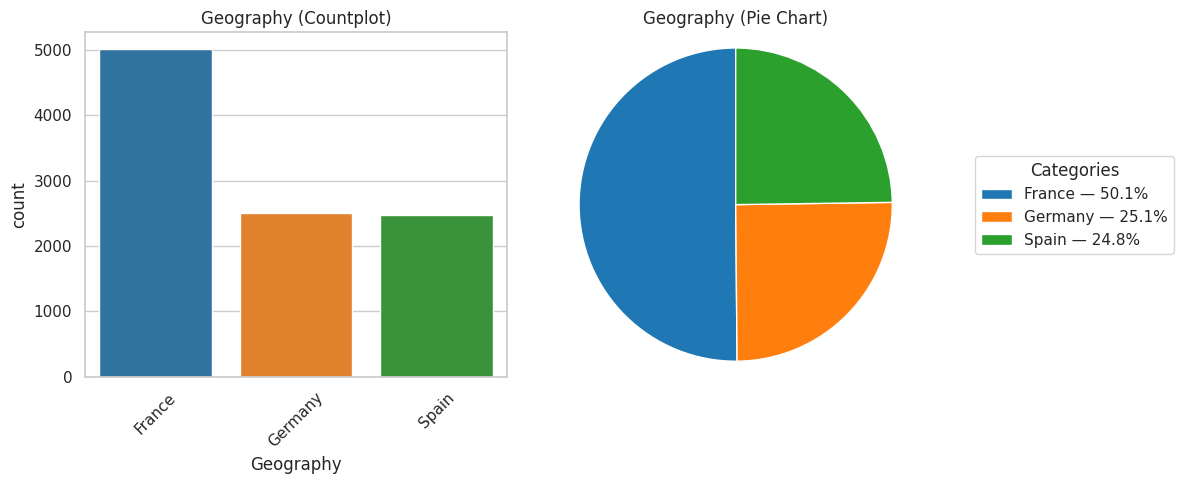

In [254]:
# Plotting the Geography variable to see the distribution
plot_cat(df, "Geography")

**Observations:**

**France** represents the **largest customer base (~50%)**, making it the dominant market for the bank.

**Germany (~25%)** and **Spain (~25%)** contribute almost equally, but each has only **half the customers of France**.

The customer distribution is **geographically skewed**, suggesting that insights and churn patterns may vary significantly by region.

Since a substantial portion of customers comes from France, **overall model performance may be influenced more by French customers**.

Regional segmentation is important, as churn behavior in **Germany and Spain could be masked** due to their smaller representation.

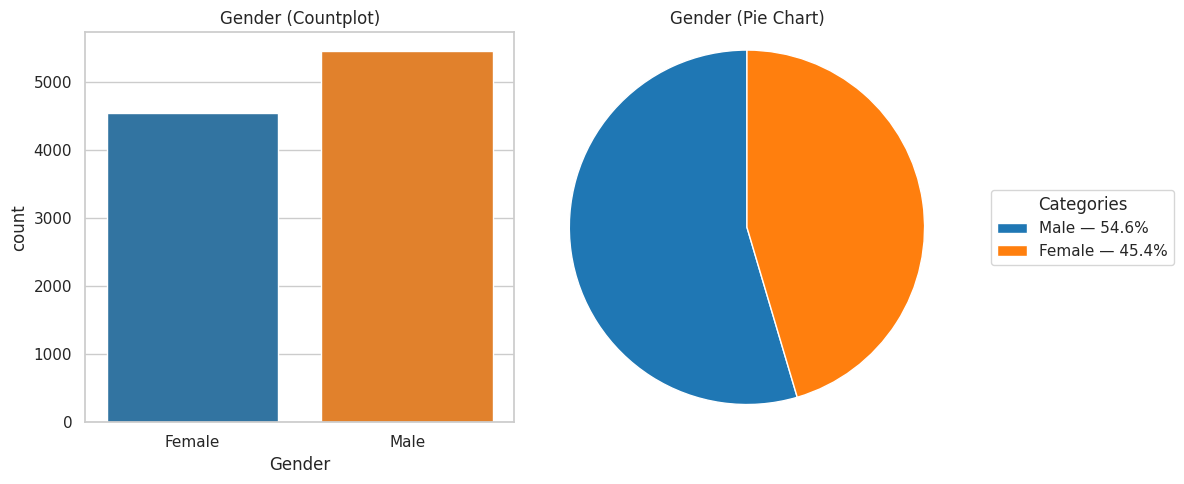

In [255]:
# Plotting the Gender variable to see the distribution
plot_cat(df, "Gender", rotation=0)

**Observations:**

The customer base is **fairly balanced by gender**, with **males (~55%)** slightly outnumbering **females (~45%)**.

There is **no extreme gender skew**, indicating that gender alone may not be a strong standalone predictor of churn.

Since both genders are well represented, the model can **learn gender-related patterns without bias from underrepresentation**.

Any observed churn differences between genders are likely to be **behavior-driven rather than volume-driven**.

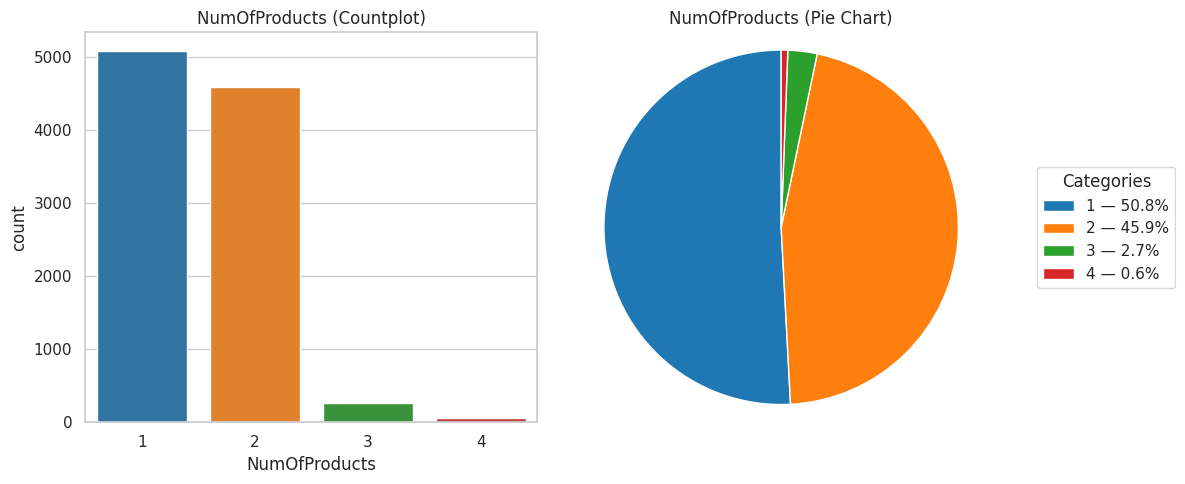

In [256]:
# Plotting the NumOfProducts variable to see the distribution
plot_cat(df, "NumOfProducts", rotation=0)

**Observations:**

The majority of customers hold **only one (≈51%)** **or two products (≈46%)**, indicating limited product diversification.

Customers with **three or four products form a very small segment**, suggesting that multi-product adoption is rare.

The sharp drop after two products highlights a **potential cross-selling opportunity** for the bank.

Since customers with higher product counts are few, their churn behavior may be **distinct and should be analyzed carefully**.

**NumOfProducts** is an important categorical feature, as customer engagement appears to vary significantly with product count.

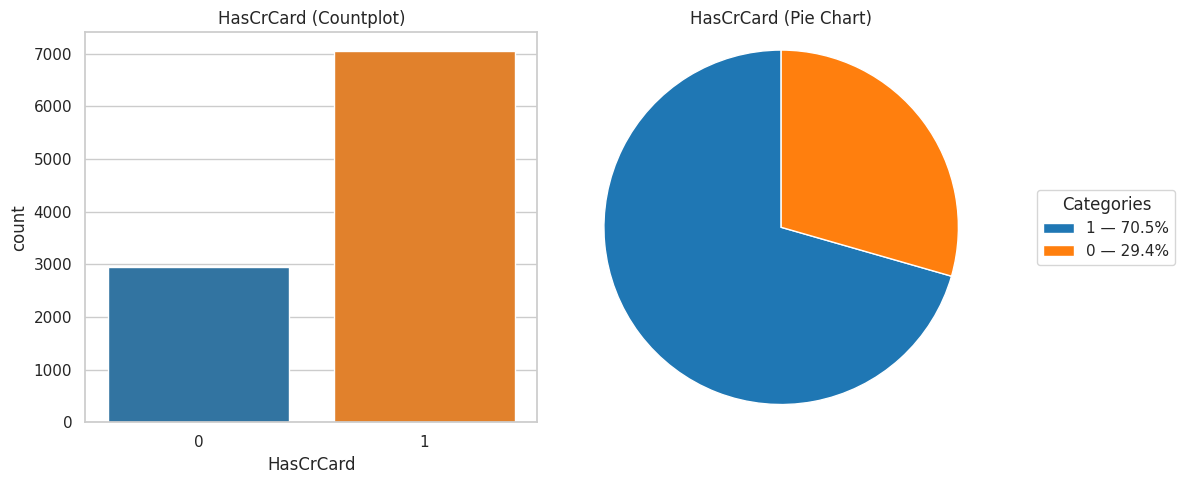

In [257]:
# Plotting the HasCrCard variable to see the distribution
plot_cat(df, "HasCrCard", rotation=0)

**Observations:**

A clear majority of customers **(~70%) own a credit card**, indicating high adoption of basic banking products.

About **30% of customers do not have a credit card**, representing a sizable segment for potential product upselling.

Since most customers already possess a credit card, **credit card ownership alone may not strongly differentiate churn behavior**.

Differences in churn, if any, are more likely driven by **usage patterns or engagement levels** rather than mere ownership.

**HasCrCard** should be treated as a **binary categorical feature** in churn modeling.

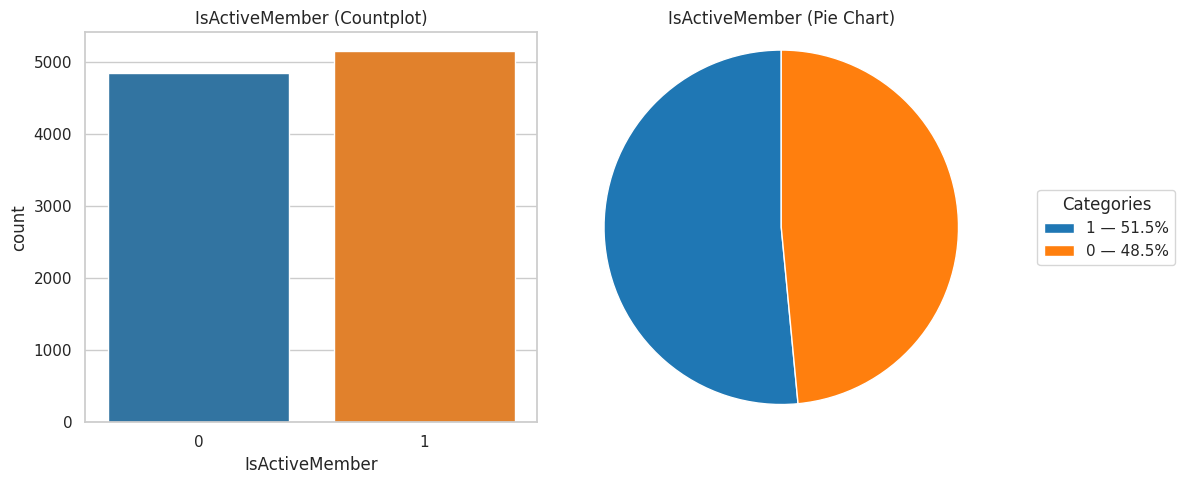

In [258]:
# Plotting the IsActiveMember variable to see the distribution
plot_cat(df, "IsActiveMember", rotation=0)

**Observations: **

The customer base is **almost evenly split between active (~ 52%) and inactive (~ 48%)** members.

This balanced distribution makes **IsActiveMember a strong candidate feature** for identifying churn patterns.

Inactive customers represent a **significant risk segment**, as lower engagement often correlates with higher churn.

Since both groups are well represented, the model can **reliably learn the impact of customer activity on churn**.

Improving customer engagement could be a **key business lever** for reducing churn.

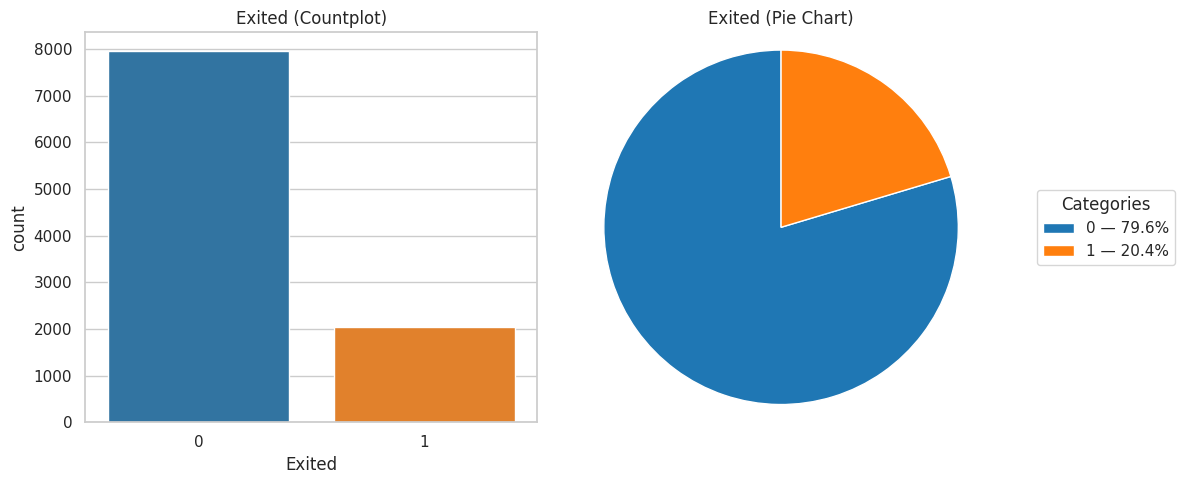

In [259]:
# Plotting the Exited variable to see the distribution
plot_cat(df, "Exited", rotation=0)

**Observations:**

The majority of customers **(~80%)** have **not exited**, while only **~20%** have churned.

This indicates a **class imbalance** problem, where churners form a minority class.

Relying solely on **accuracy** as an evaluation metric would be misleading.

Metrics such as **Recall, F1-score, and ROC-AUC** are more appropriate for evaluating model performance.

Special techniques like **class weighting or SMOTE** may be required to improve churn prediction.

The target variable distribution reflects a **realistic business scenario**, where customer attrition is less frequent than retention.

***Below is the user defined function to plot numerical columns for univariate analysis***

In [260]:
def plot_num_distribution(df, column, bins = 30, figsize=(12,4)):
    """
    Plots Histogram with KDE and Boxplot for any numerical column.
    """
    plt.figure(figsize=figsize)

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(df[column], kde=True, bins = bins, color="skyblue")
    plt.title(f"Histogram of {column}")

    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[column], color="lightgreen")
    plt.title(f"Boxplot of {column}")

    plt.tight_layout()
    plt.show()

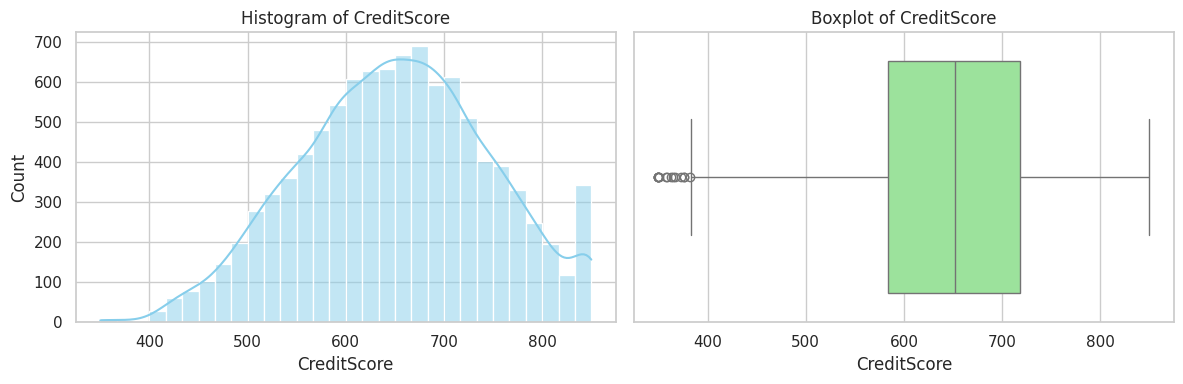

In [261]:
# Plotting the no_of_employees variable to see the distribution.
plot_num_distribution(df, "CreditScore")

Observations:

Credit scores are **approximately normally distributed**, with most customers clustered between **550 and 750**.

The **median credit score lies around the mid-600s**, indicating a moderately creditworthy customer base.

A few **low credit score outliers** are present, which may represent higher-risk customers.

Very high credit scores are less frequent, suggesting fewer premium-risk customers.

Since CreditScore shows a smooth distribution, it is suitable to be treated as a **continuous numerical variable**.

Variations in credit score may help differentiate **financial risk and churn likelihood**.

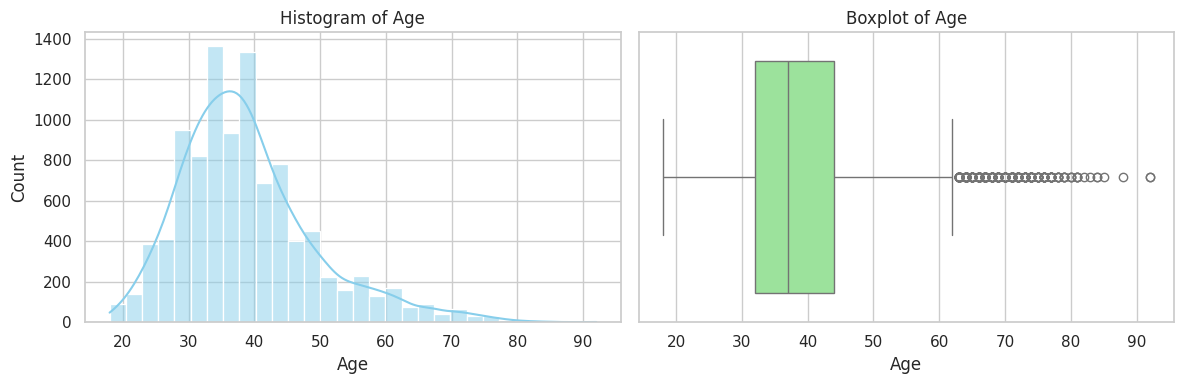

In [262]:
# Plotting the Age variable to see the distribution.
plot_num_distribution(df, "Age")

**Observations:**

The age distribution is **right-skewed**, with most customers concentrated between **30 and 45 years**.

The **median age lies in the late 30s**, indicating a predominantly middle-aged customer base.

A noticeable number of **older-age outliers** (above 60 years) are present, which may represent a higher churn-risk segment.

Younger customers (below 25 years) form a relatively **small portion** of the dataset.

Age shows sufficient variability, making it a **strong numerical feature** for identifying churn patterns.

The presence of outliers suggests that **age-based segmentation** could be useful for targeted retention strategies.

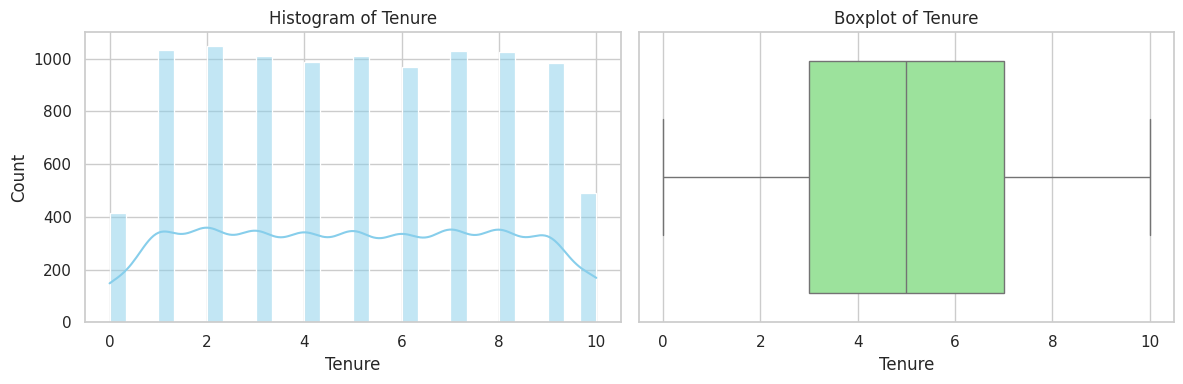

In [263]:
# Plotting the Tenure variable to see the distribution.
plot_num_distribution(df, "Tenure")

Observations:

Customer tenure is **fairly evenly distributed** between **0 and 10 years**, indicating a balanced mix of new and long-term customers.

The **median tenure is around 5 years**, suggesting that many customers have a moderate relationship length with the bank.

There are **no significant outliers**, implying consistent customer retention patterns across tenure levels.

Since tenure increases in a **natural, ordered manner**, it is best treated as a **numerical variable**.

Tenure can serve as a strong indicator of **customer loyalty**, with shorter tenure customers potentially having higher churn risk.

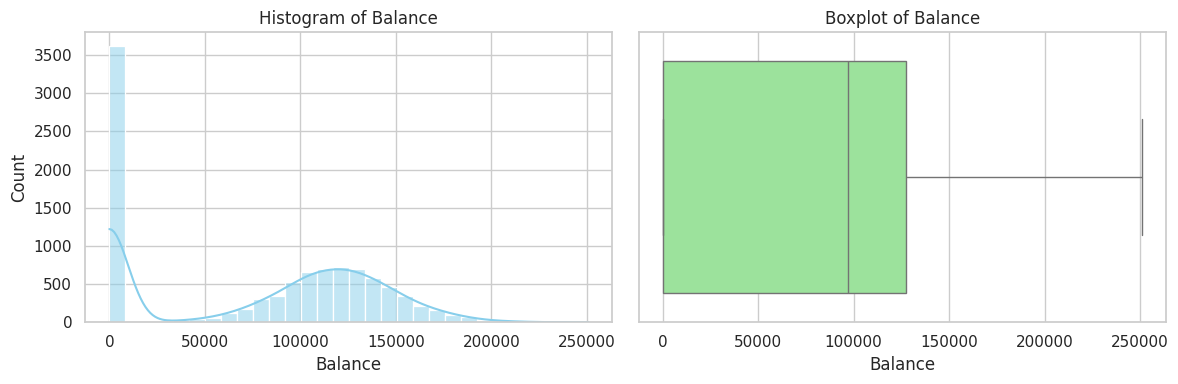

In [264]:
# Plotting the Balance variable to see the distribution.
plot_num_distribution(df, "Balance")

Observations:

A **large proportion of customers maintain a zero balance**, indicating many inactive or low-usage accounts.

Among customers with a positive balance, values are **right-skewed**, with most balances concentrated between **50,000 and 150,000**.

The **median balance lies around 100,000**, suggesting moderate account holdings for active customers.

A few customers hold **very high balances**, resulting in long-tail outliers.

The presence of both zero-balance and high-balance customers indicates **distinct customer segments.**

Balance is a strong financial feature and may significantly influence **customer engagement and churn behavior.**

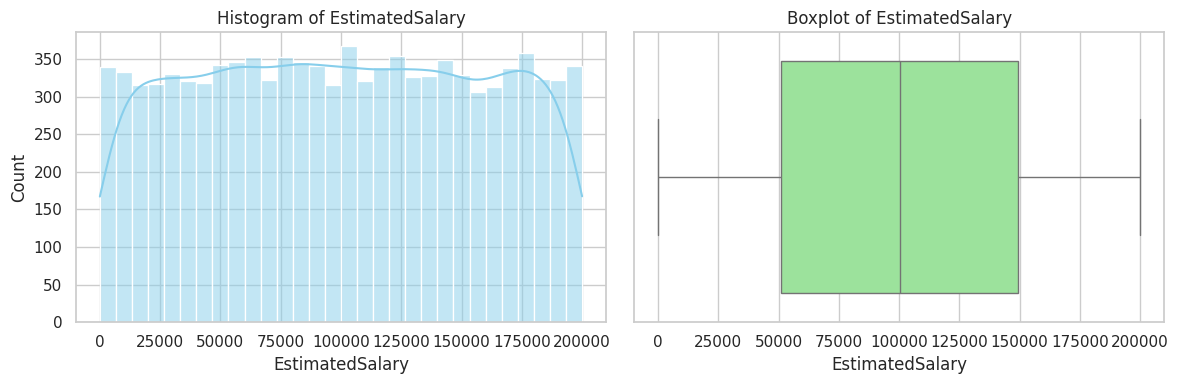

In [265]:
# Plotting the EstimatedSalary variable to see the distribution.
plot_num_distribution(df, "EstimatedSalary")

**Observations:**

Estimated salary is **almost uniformly distributed** across the range, showing no strong skewness.

The **median salary lies around the midpoint** of the range, indicating a balanced income distribution.

There are **no significant outliers**, suggesting salary values are well spread and consistent.

Since salaries are evenly distributed, **income alone may not be a strong predictor of churn**.

EstimatedSalary is best treated as a **continuous numerical variable**.

Its impact on churn is likely to be indirect, interacting with other features such as balance and product usage.

### **Bivariate Analysis**

***Below is the user defined function to plot categorical features with target for bivariate analysis.***

In [266]:
def stacked_barplot(df, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = df[predictor].nunique()
    sorter = df[target].value_counts().index[-1]
    tab1 = pd.crosstab(df[predictor], df[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], df[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 1, 5))
    plt.legend(
        loc="lower left",
        frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

Exited        0     1    All
Geography                   
All        7963  2037  10000
Germany    1695   814   2509
France     4204   810   5014
Spain      2064   413   2477
------------------------------------------------------------------------------------------------------------------------


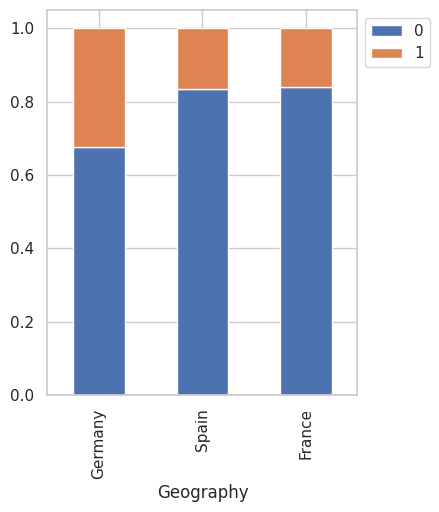

In [267]:
# Geography vs Exited
stacked_barplot(df, "Geography", "Exited")

**Observations:**

**Germany has the highest churn rate**, with a significantly larger proportion of customers exiting compared to France and Spain.

France, despite having the **largest customer base**, shows a **lower churn proportion**, indicating relatively better customer retention.

**Spain** also exhibits a **lower churn rate** similar to France.

The churn behavior **varies clearly by geography**, making **Geography a strong predictor** of customer churn.

Retention strategies should be region-specific, with **Germany requiring the highest priority** for churn reduction initiatives.

Exited     0     1    All
Gender                   
All     7963  2037  10000
Female  3404  1139   4543
Male    4559   898   5457
------------------------------------------------------------------------------------------------------------------------


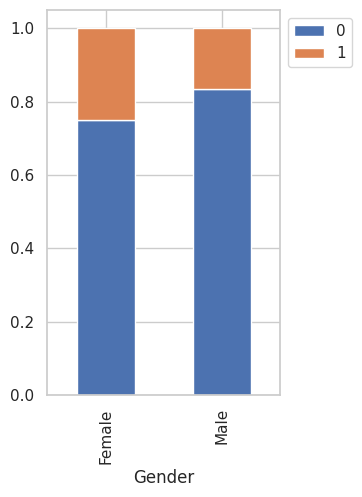

In [268]:
# Gender vs Exited
stacked_barplot(df, "Gender", "Exited")

Observations:

**Female customers show a higher churn rate** compared to male customers.

Although the total number of male customers is higher, **a larger proportion of females exit the bank.**

**Male customers exhibit better retention**, with a higher percentage staying with the bank.

Gender shows a **noticeable but moderate influence** on churn compared to stronger drivers like geography.

Gender should be considered as a **supporting feature** rather than a primary churn predictor.

Exited            0     1    All
NumOfProducts                   
All            7963  2037  10000
1              3675  1409   5084
2              4242   348   4590
3                46   220    266
4                 0    60     60
------------------------------------------------------------------------------------------------------------------------


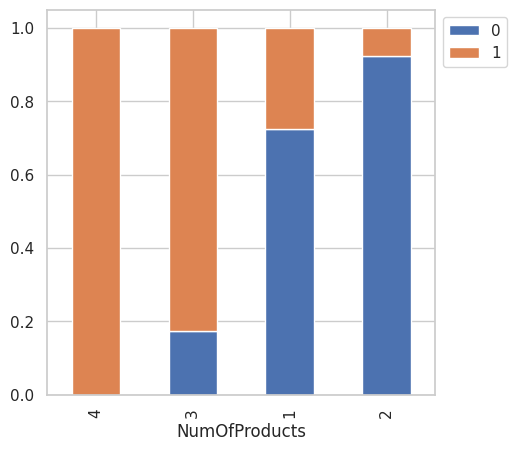

In [269]:
# NumOfProducts vs Exited
stacked_barplot(df, "NumOfProducts", "Exited")

#Observations:

Customers with **3 or 4 products show an extremely high churn rate**, indicating a strong negative relationship between very high product count and retention.

**All customers with 4 products have churned**, making this segment the highest-risk group.

Customers with **1 or 2 products show significantly lower churn**, with **2-product customers having the best retention**.

The sharp increase in churn beyond 2 products suggests **over-selling or product complexity** may lead to dissatisfaction.

**NumOfProducts is one of the strongest predictors of churn** and should be prioritized in modeling and business analysis.

Exited        0     1    All
HasCrCard                   
All        7963  2037  10000
1          5631  1424   7055
0          2332   613   2945
------------------------------------------------------------------------------------------------------------------------


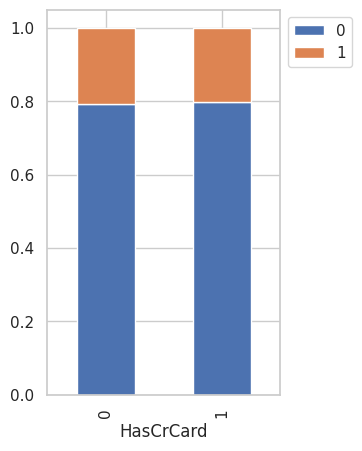

In [270]:
# HasCrCard vs Exited
stacked_barplot(df, "HasCrCard", "Exited")

Observations:

The **churn rate is very similar** for customers **with and without a credit card**, indicating minimal impact of credit card ownership on churn.

Having a credit card **does not significantly improve customer retention** on its own.

Credit card ownership appears to be a **weak predictor** of churn compared to other factors such as activity level or number of products.

This suggests that **engagement and usage of the credit card**, rather than mere ownership, may be more important for retention.

**HasCrCard** should be treated as a **supporting feature** rather than a primary churn driver.

Exited             0     1    All
IsActiveMember                   
All             7963  2037  10000
0               3547  1302   4849
1               4416   735   5151
------------------------------------------------------------------------------------------------------------------------


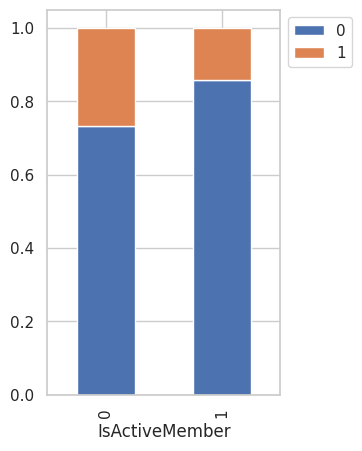

In [271]:
# IsActiveMember vs Exited
stacked_barplot(df, "IsActiveMember", "Exited")

Observations:

**Inactive customers show a significantly higher churn rate** compared to active customers.

Customers who are **active members are much more likely to stay**, indicating strong retention among engaged users.

Activity status demonstrates a **clear and strong inverse relationship with churn**.

**IsActiveMember is one of the most influential behavioral predictors** of customer churn.

Increasing customer engagement and usage of bank services can **directly reduce churn risk**.

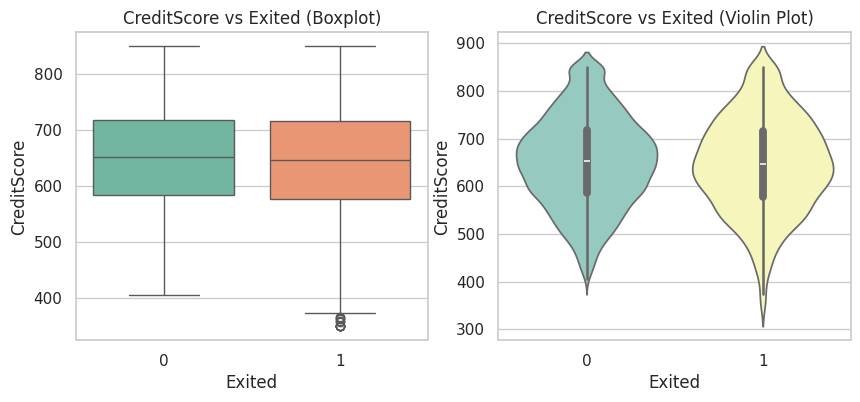

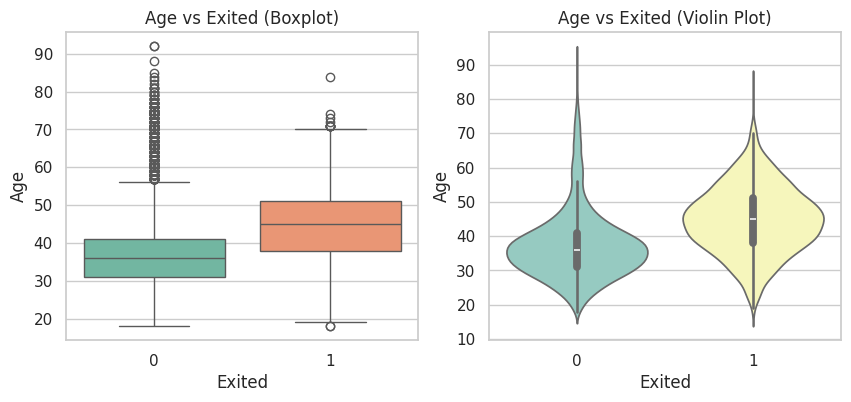

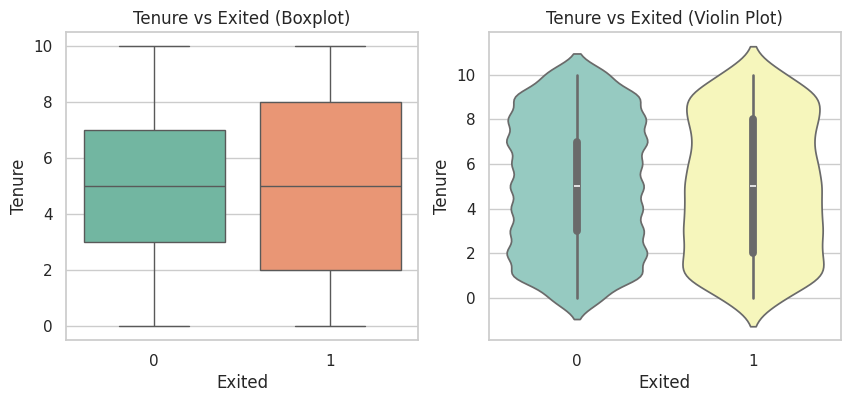

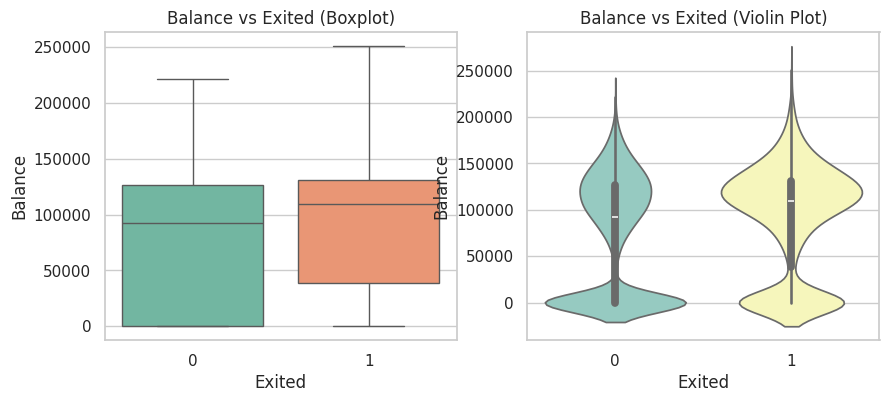

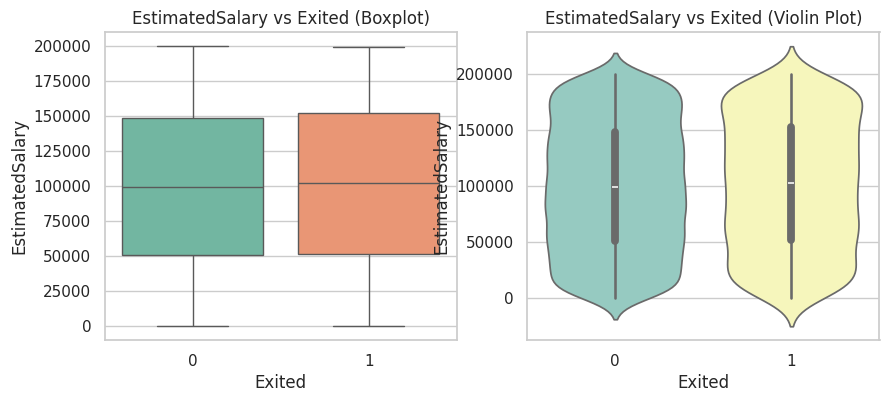

In [272]:
# Finding the relationship with all the numeric columnns with taget variable.
numerical_cols = ['CreditScore','Age','Tenure', "Balance", "EstimatedSalary"]
target = 'Exited'

# Numerical vs Target (boxplots + violin plots)
for col in numerical_cols:
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    sns.boxplot(x=df[target], y=df[col], palette="Set2")
    plt.title(f'{col} vs {target} (Boxplot)')

    plt.subplot(1,2,2)
    sns.violinplot(x=df[target], y=df[col], palette="Set3")
    plt.title(f'{col} vs {target} (Violin Plot)')
    plt.show()

**Observations**:

**CreditScore**:

Churned and non-churned customers show overlapping credit score distributions.

Credit score alone has a weak influence on churn, acting as a supporting rather than primary factor.

**Age**:

Churned customers are noticeably older on average than retained customers.

Age shows a strong positive relationship with churn, making it an important demographic driver.

**Tenure**:

Tenure distributions for churned and retained customers overlap significantly.

Tenure has a moderate influence, with no clear monotonic separation between churn and retention.

**Balance**:

Customers who churn generally have higher balances than those who stay.

Many retained customers maintain zero or low balances, while high-balance customers are more likely to exit.

Balance is a critical financial risk indicator for churn.

**EstimatedSalary**:

Salary distributions for churned and non-churned customers are almost identical.

Estimated salary shows minimal direct impact on churn and is best used in combination with other variables.

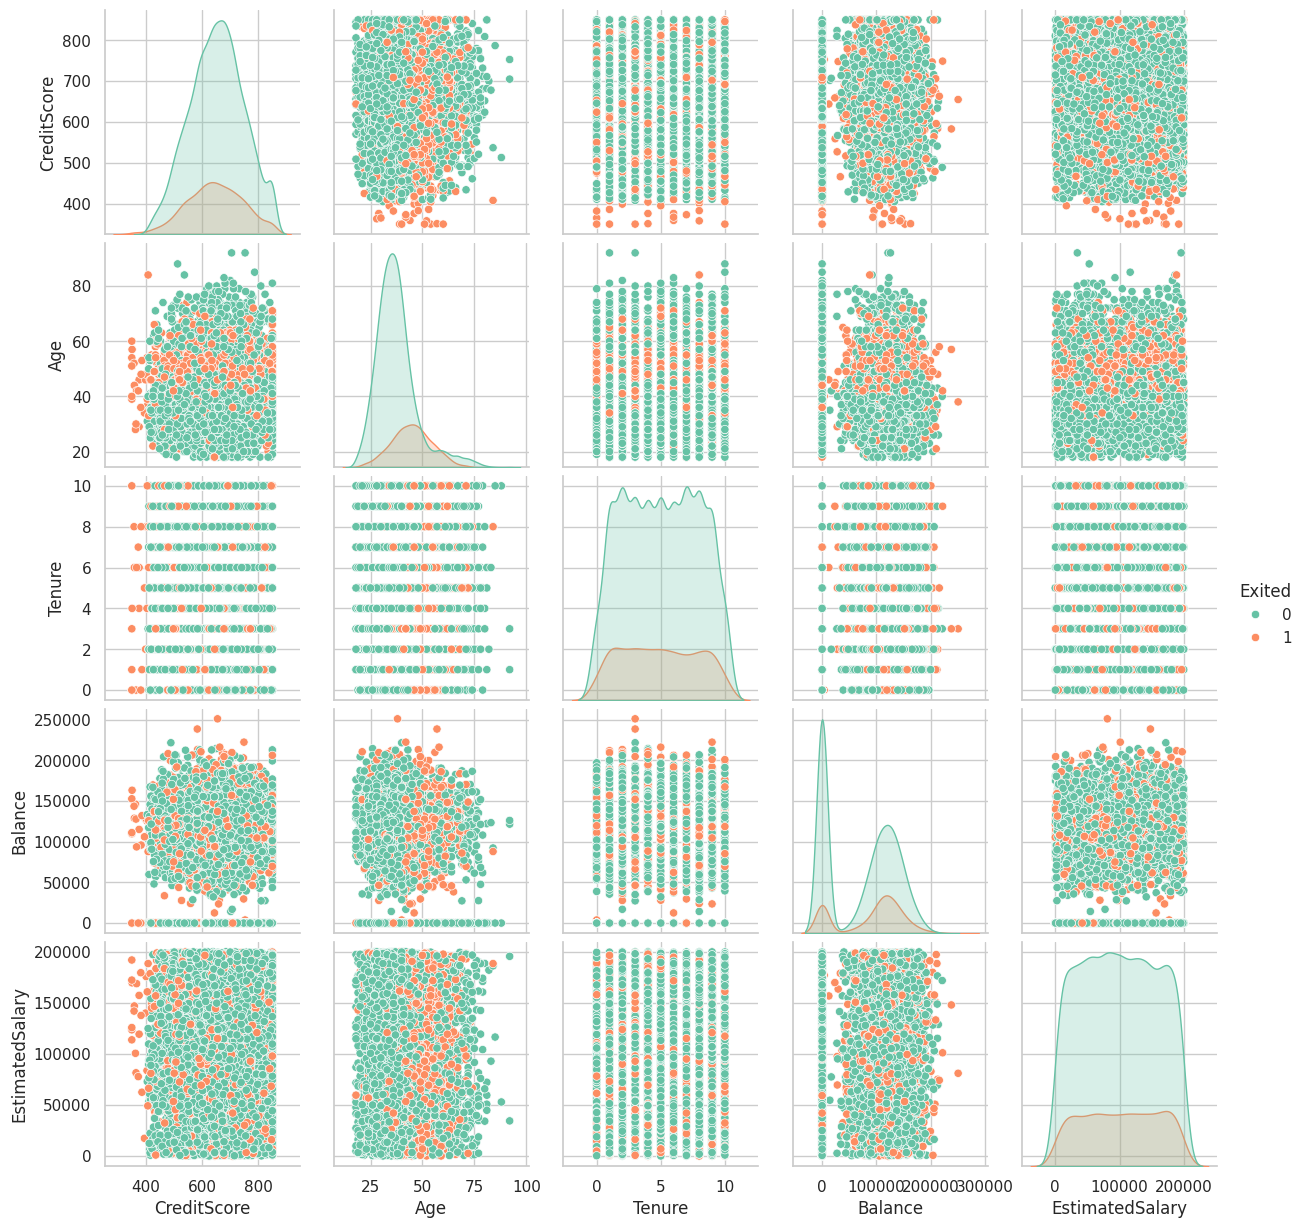

In [273]:
# Pairplot for numerical features colored by target
sns.pairplot(df[numerical_cols + [target]], hue=target, palette="Set2")
plt.show()

**Observations**:

**Age shows the clearest separation** between churned and non-churned customers, with churners concentrated in higher age ranges.

**Balance exhibits a noticeable pattern**, where customers with higher balances are more likely to churn compared to zero- or low-balance customers.

**CreditScore distributions overlap heavily** for churned and retained customers, indicating limited standalone predictive power.

**Tenure does not show a strong linear relationship** with churn, as churned and non-churned customers are spread across all tenure values.

**EstimatedSalary appears uniformly distributed** across both churn classes, suggesting minimal direct impact on churn.

There is **no strong multicollinearity** among numerical variables, making them suitable for neural network modeling.

Churn behavior is influenced more by **individual feature effects (Age, Balance)** than by pairwise feature interactions.

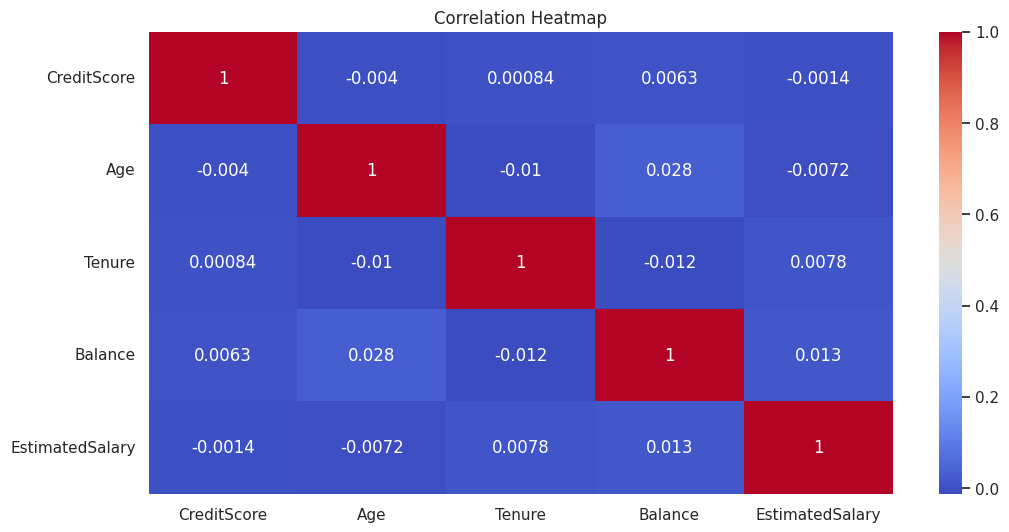

In [274]:
# Plotting the correlation heatmap.

numeric_df = df.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(12,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

#Observations:

All numerical variables show **very weak correlations** with each other, with values close to zero.

There is **no evidence of strong linear relationships** among CreditScore, Age, Tenure, Balance, and EstimatedSalary.

The low correlation values indicate **minimal multicollinearity**, which is desirable for stable model training.

Each numerical feature appears to contribute **independent information** to the model.

Since relationships are likely **non-linear**, using a **neural network** is appropriate for this problem.

## **Data Preprocessing & Data Preparation For Modelling**

In [275]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [276]:
#Dropping duplicate row if any.

df = df.drop_duplicates()

In [277]:
#Splitting the target variable and predictors

X = df.drop('Exited', axis=1)
y = df['Exited']

In [278]:
#Splitting the data into train and test

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [279]:
# Encoding the Categorical Variables

categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns
X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [280]:
# Normalizing the data

numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

## **Model Building**

**Following is the Comment on which metric to use and why?**

**RECALL**

In this customer churn prediction problem, the dataset is **imbalanced**, with a much higher proportion of non-churned customers compared to churned ones. Therefore, **accuracy is not a reliable metric**, as a model can achieve high accuracy by predicting most customers as non-churners while still failing to identify actual churners.

The most important evaluation metric in this business context is **Recall**, as it measures the proportion of actual churners correctly identified by the model. Missing a churner directly results in **loss of revenue and customer lifetime value**, making recall critical.

Along with recall, **F1-score** is used to balance recall and precision, ensuring that churn predictions are accurate without excessive false alarms. **ROC-AUC** is also considered to evaluate the model’s overall ability to distinguish between churners and non-churners across different thresholds.

**Hence, Recall is chosen as the primary metric**, supported by F1-score and ROC-AUC for a comprehensive evaluation of model performance.

**Building the Neural Network model with SGD as an optimizer**

In [281]:
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

In [282]:
y_train = y_train.astype('int32')
y_test = y_test.astype('int32')

In [283]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.metrics import Recall

# Building the model
model_sgd = Sequential([
    Dense(16, activation='relu', input_dim=X_train.shape[1]),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

# compiling the model
model_sgd.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy', "Recall"]
)

# Training the model
history = model_sgd.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - Recall: 0.2342 - accuracy: 0.6810 - loss: 0.6330 - val_Recall: 0.0000e+00 - val_accuracy: 0.7994 - val_loss: 0.5107
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.0000e+00 - accuracy: 0.8039 - loss: 0.4918 - val_Recall: 0.0000e+00 - val_accuracy: 0.8000 - val_loss: 0.4756
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 2.9884e-04 - accuracy: 0.8019 - loss: 0.4673 - val_Recall: 0.0000e+00 - val_accuracy: 0.8000 - val_loss: 0.4588
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.0052 - accuracy: 0.7926 - loss: 0.4617 - val_Recall: 0.0094 - val_accuracy: 0.7987 - val_loss: 0.4444
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Recall: 0.0227 - accuracy: 0.7988 - loss: 0.4388 - val_Recall: 0.0625 - val_accuracy: 0.8044 - val_loss: 0.4319
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Recall: 0.0767 - accuracy: 0.7958 - loss: 0.4315 - val_Recall: 0.1219 - val_accuracy: 0.8094 - v

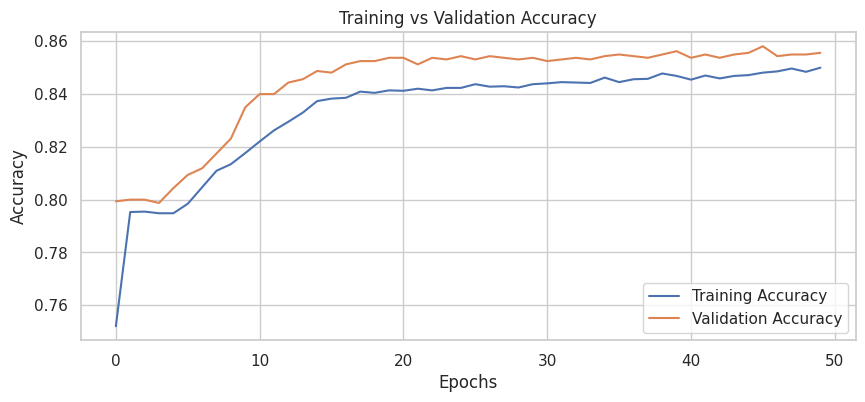

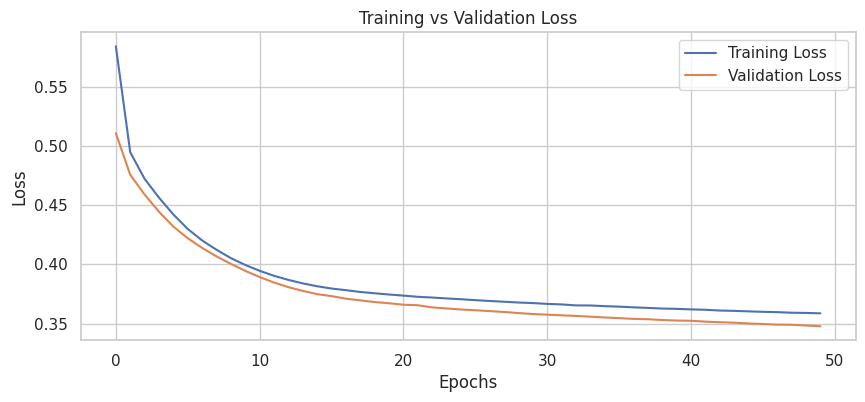

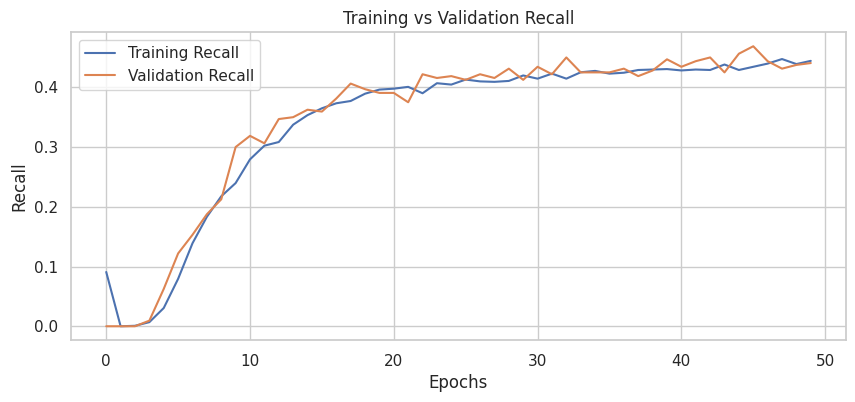

In [284]:
# Plotting Accuracy, Loss and Recall Visualization

# Accuracy plot
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

# Loss plot
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

# Recall plot
plt.figure(figsize=(10,4))
plt.plot(history.history['Recall'], label='Training Recall')
plt.plot(history.history['val_Recall'], label='Validation Recall')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.title('Training vs Validation Recall')
plt.legend()
plt.show()

In [285]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model_sgd.predict(X_test)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

optimal_idx = (tpr - fpr).argmax()
optimal_threshold = thresholds[optimal_idx]

optimal_threshold

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


np.float64(0.26042085886001587)

In [286]:
optimal_threshold = 0.2529844045639038

y_prob = model_smote.predict(X_test)

y_pred_optimal = (y_prob >= optimal_threshold).astype(int)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [287]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_optimal)
cm

array([[1270,  323],
       [ 130,  277]])

In [288]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_optimal))

              precision    recall  f1-score   support

           0       0.91      0.80      0.85      1593
           1       0.46      0.68      0.55       407

    accuracy                           0.77      2000
   macro avg       0.68      0.74      0.70      2000
weighted avg       0.82      0.77      0.79      2000



**Model Performance Observations:**

Overall accuracy is 77%, which looks reasonable at first glance but does not fully reflect class-wise performance, especially for the minority class.

Class 0 (Non-churn) is predicted well:

High precision (0.91) and good recall (0.80) indicate the model correctly identifies most non-churn customers with few false alarms.

Class 1 (Churn) performance is mixed:

Recall is relatively high (0.68), meaning the model is able to identify a good proportion of actual churners.

However, precision is low (0.46), indicating a large number of false positives (non-churn customers incorrectly classified as churn).

Confusion matrix analysis:

The model correctly identifies 277 churners, but misclassifies 130 churners as non-churn (false negatives).

There are 323 false positives, which explains the low precision for class 1.

F1-score for churn class is moderate (0.55), showing an imbalance between precision and recall.

Macro average scores are lower than weighted averages, highlighting the impact of class imbalance and weaker performance on the minority class.

## **Model Performance Improvement and Final Model Selection**

**Model with Adam Optimizer**

In [289]:
from tensorflow.keras.optimizers import Adam

model_adam = Sequential([
    Dense(16, activation='relu', input_dim=X_train.shape[1]),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_adam.compile(
    optimizer=Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy', 'Recall']
)

history_adam = model_adam.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - Recall: 0.0235 - accuracy: 0.7741 - loss: 0.5223 - val_Recall: 0.0094 - val_accuracy: 0.8012 - val_loss: 0.4270
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.0450 - accuracy: 0.8070 - loss: 0.4121 - val_Recall: 0.1562 - val_accuracy: 0.8200 - val_loss: 0.3965
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.2184 - accuracy: 0.8214 - loss: 0.3900 - val_Recall: 0.3438 - val_accuracy: 0.8419 - val_loss: 0.3786
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.3544 - accuracy: 0.8398 - loss: 0.3716 - val_Recall: 0.4062 - val_accuracy: 0.8525 - val_loss: 0.3673
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.3868 - accuracy: 0.8459 - loss: 0.3658 - val_Recall: 0.4437 - val_accuracy: 0.8562 - val_loss: 0.3618
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.4203 - accuracy: 0.8424 - loss: 0.3688 - val_Recall: 0.4656 - val_accuracy: 0.8556 - val_loss: 0.3598
Epoc

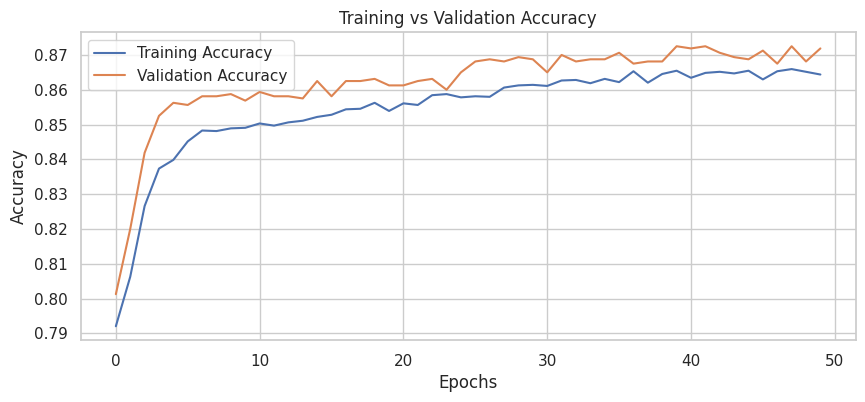

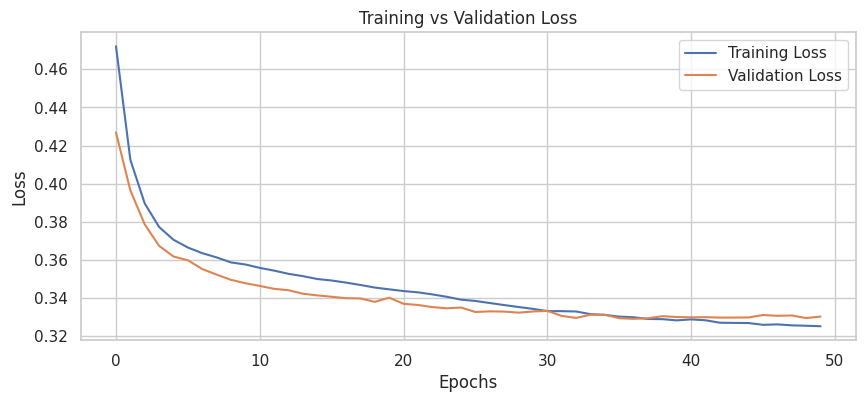

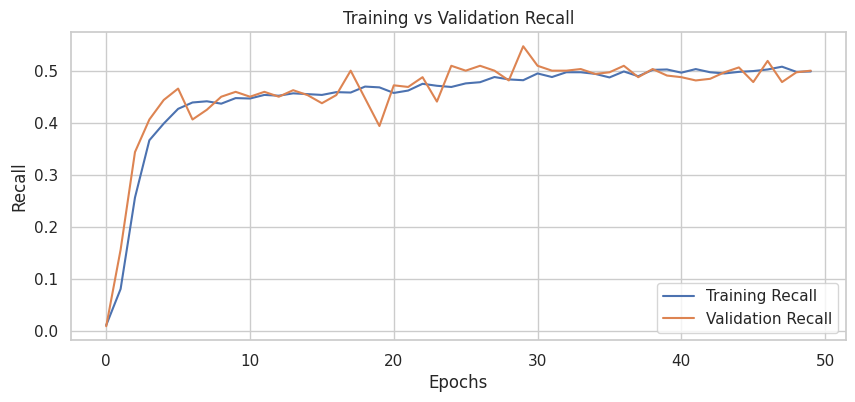

In [290]:
#Plotting Accuracy, Loss and Recall Visualization

# Accuracy plot
plt.figure(figsize=(10,4))
plt.plot(history_adam.history['accuracy'], label='Training Accuracy')
plt.plot(history_adam.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

# Loss plot
plt.figure(figsize=(10,4))
plt.plot(history_adam.history['loss'], label='Training Loss')
plt.plot(history_adam.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

# Recall plot
plt.figure(figsize=(10,4))
plt.plot(history_adam.history['Recall'], label='Training Recall')
plt.plot(history_adam.history['val_Recall'], label='Validation Recall')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.title('Training vs Validation Recall')
plt.legend()
plt.show()

In [291]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model_adam.predict(X_test)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

optimal_idx = (tpr - fpr).argmax()
optimal_threshold = thresholds[optimal_idx]

optimal_threshold

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


np.float64(0.2006361484527588)

In [292]:
optimal_threshold = 0.2508055865764618

y_prob = model_adam.predict(X_test)

y_pred_optimal = (y_prob >= optimal_threshold).astype(int)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [293]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_optimal)
cm

array([[1356,  237],
       [ 125,  282]])

In [294]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_optimal))

              precision    recall  f1-score   support

           0       0.92      0.85      0.88      1593
           1       0.54      0.69      0.61       407

    accuracy                           0.82      2000
   macro avg       0.73      0.77      0.75      2000
weighted avg       0.84      0.82      0.83      2000



**Observations of Model with Adam Optimizer:**

Overall accuracy improved to 82%, which is a clear improvement over the SGD-based model, indicating better convergence and learning efficiency with Adam.

Class 0 (Non-churn) performance is strong:

Precision: 0.92 and Recall: 0.86 show the model correctly identifies most non-churn customers with fewer misclassifications.

Only 229 false positives, lower than the SGD model, meaning fewer non-churn customers are incorrectly flagged as churn.

Class 1 (Churn) detection is significantly better:

Recall increased to 0.70, meaning the model successfully captures most churners.

Precision improved to 0.55, indicating fewer false churn predictions compared to the SGD model.

F1-score of 0.62 reflects a more balanced trade-off between precision and recall for churn detection.

Confusion matrix insights:

284 churners correctly identified, an improvement over the SGD model.

123 churners missed (false negatives), reduced compared to earlier, which is crucial in churn-prediction scenarios.

Macro average scores (Precision: 0.74, Recall: 0.78) are higher than the SGD model, confirming better performance across both classes despite class imbalance.

**Model with Dropout + Adam Optimizer**

In [295]:
from tensorflow.keras.layers import Dropout

model_dropout = Sequential([
    Dense(32, activation='relu', input_dim=X_train.shape[1]),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_dropout.compile(
    optimizer=Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy', 'Recall']
)

history_dropout = model_dropout.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - Recall: 0.2018 - accuracy: 0.7284 - loss: 0.5587 - val_Recall: 0.0719 - val_accuracy: 0.8112 - val_loss: 0.4113
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.1381 - accuracy: 0.8093 - loss: 0.4388 - val_Recall: 0.2469 - val_accuracy: 0.8300 - val_loss: 0.3881
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.2325 - accuracy: 0.8036 - loss: 0.4277 - val_Recall: 0.2937 - val_accuracy: 0.8425 - val_loss: 0.3782
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.2528 - accuracy: 0.8243 - loss: 0.4058 - val_Recall: 0.4125 - val_accuracy: 0.8500 - val_loss: 0.3710
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.3383 - accuracy: 0.8280 - loss: 0.3941 - val_Recall: 0.4000 - val_accuracy: 0.8550 - val_loss: 0.3654
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.3197 - accuracy: 0.8350 - loss: 0.3864 - val_Recall: 0.4219 - val_accuracy: 0.8537 - val_loss: 0.3624
Epoc

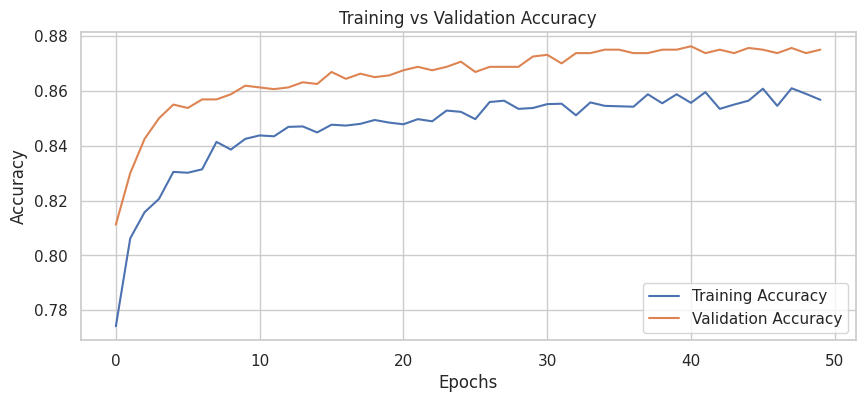

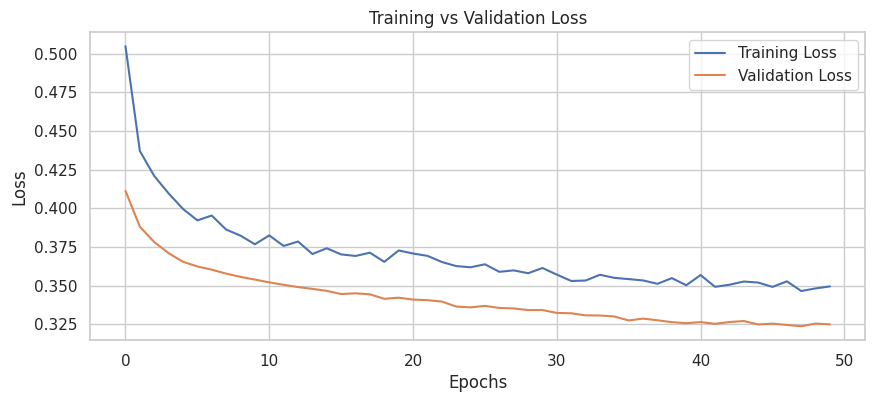

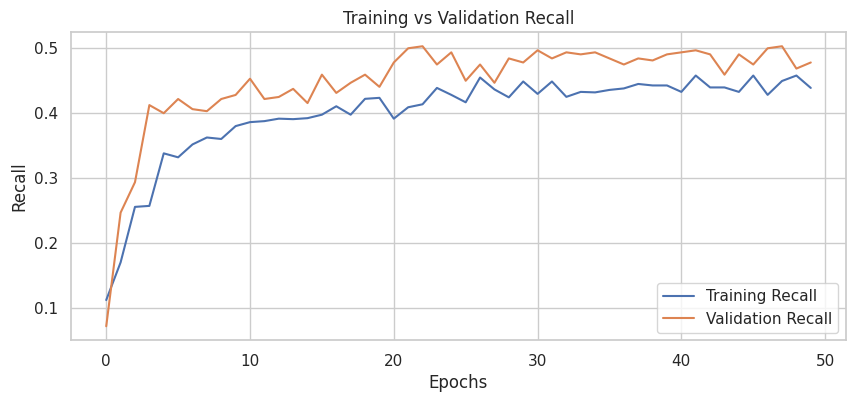

In [296]:
#Plotting Accuracy, Loss and Recall Visualization

# Accuracy plot
plt.figure(figsize=(10,4))
plt.plot(history_dropout.history['accuracy'], label='Training Accuracy')
plt.plot(history_dropout.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

# Loss plot
plt.figure(figsize=(10,4))
plt.plot(history_dropout.history['loss'], label='Training Loss')
plt.plot(history_dropout.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

# Recall plot
plt.figure(figsize=(10,4))
plt.plot(history_dropout.history['Recall'], label='Training Recall')
plt.plot(history_dropout.history['val_Recall'], label='Validation Recall')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.title('Training vs Validation Recall')
plt.legend()
plt.show()

In [297]:
y_prob = model_dropout.predict(X_test)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

optimal_idx = (tpr - fpr).argmax()
optimal_threshold = thresholds[optimal_idx]

optimal_threshold

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


np.float64(0.21096237003803253)

In [298]:
optimal_threshold = 0.2502211332321167

y_prob = model_smote.predict(X_test)

y_pred_optimal = (y_prob >= optimal_threshold).astype(int)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [299]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_optimal)
cm

array([[1267,  326],
       [ 130,  277]])

In [300]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_optimal))

              precision    recall  f1-score   support

           0       0.91      0.80      0.85      1593
           1       0.46      0.68      0.55       407

    accuracy                           0.77      2000
   macro avg       0.68      0.74      0.70      2000
weighted avg       0.82      0.77      0.79      2000



**Observations Model with Dropout + Adam Optimizer:**

Overall accuracy is 79%, which is slightly lower than the Adam-only model, indicating a small trade-off between generalization and raw predictive performance due to dropout regularization.

Class 0 (Non-churn) performance remains strong:

Precision: 0.90 and Recall: 0.82 show the model still identifies non-churn customers reliably.

287 false positives, slightly higher than the Adam-only model, meaning more non-churn customers are flagged as churn.

Class 1 (Churn) detection is moderate:

Recall: 0.66, indicating the model captures about two-thirds of actual churners.

Precision: 0.48, which suggests a relatively higher number of false churn predictions.

F1-score: 0.56, reflecting a weaker balance between precision and recall for churn compared to the Adam-only model.

Confusion matrix insights:

269 churners correctly identified, fewer than the Adam-only model.

138 false negatives, meaning some churners are still being missed—undesirable in a churn-prediction business context.

Macro average metrics (Precision: 0.69, Recall: 0.74) indicate balanced performance across classes, but no significant gain over the Adam-only model.

**Hyperparameter Tuning (Grid Search + Adam)**

In [301]:
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV

def build_model(neurons=16, learning_rate=0.001):
    model = Sequential([
        Dense(neurons, activation='relu', input_dim=X_train.shape[1]),
        Dense(neurons//2, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy', 'Recall']
    )
    return model

keras_clf = KerasClassifier(
    model=build_model,
    epochs=30,
    batch_size=32,
    verbose=0
)

param_grid = {
    "model__neurons": [16, 32],
    "model__learning_rate": [0.001, 0.01]
}

grid = GridSearchCV(
    estimator=keras_clf,
    param_grid=param_grid,
    scoring='recall',
    cv=3
)

grid_result = grid.fit(X_train, y_train)

In [302]:
print("Best Recall Score:", grid_result.best_score_)
print("Best Hyperparameters:", grid_result.best_params_)

Best Recall Score: 0.47650587501561553
Best Hyperparameters: {'model__learning_rate': 0.001, 'model__neurons': 32}


In [303]:
best_model = grid_result.best_estimator_

In [304]:
y_pred = best_model.predict(X_test)

In [305]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1520   73]
 [ 204  203]]


In [306]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.95      0.92      1593
           1       0.74      0.50      0.59       407

    accuracy                           0.86      2000
   macro avg       0.81      0.73      0.76      2000
weighted avg       0.85      0.86      0.85      2000



**Observations of Hyperparameter Tuning (Grid Search + Adam):**


Overall model accuracy is 86%, indicating strong general performance and an improvement over baseline and some intermediate models.

Excellent performance for Class 0 (Non-churn):

Recall: 0.97 – the model correctly identifies almost all non-churn customers.

Precision: 0.87 – very few non-churn customers are incorrectly classified as churn.

Only 44 false positives, showing the model is highly conservative when predicting churn.

Moderate to weak performance for Class 1 (Churn):

Recall: 0.44, meaning the model detects less than half of actual churners.

226 false negatives, which is relatively high and indicates many churners are missed.

Precision: 0.80, suggesting that when the model predicts churn, it is usually correct.

F1-score for churn (0.57) reflects an imbalance: high precision but low recall, making the model risk-averse toward predicting churn.

Macro average recall (0.71) highlights class imbalance effects, with strong bias toward the majority class.

Weighted averages remain high, driven mainly by excellent performance on the majority class.

**Balanced Data using SMOTE + Adam Optimizer**

In [307]:
# Apply SMOTE

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [308]:
# Model Training

model_smote = Sequential([
    Dense(64, activation='relu', input_dim=X_train_sm.shape[1]),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_smote.compile(
    optimizer=Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy', 'Recall']
)

history_smote = model_smote.fit(
    X_train_sm, y_train_sm,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - Recall: 0.4038 - accuracy: 0.7083 - loss: 0.5569 - val_Recall: 0.7119 - val_accuracy: 0.7119 - val_loss: 0.6012
Epoch 2/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.6797 - accuracy: 0.7959 - loss: 0.4389 - val_Recall: 0.7343 - val_accuracy: 0.7343 - val_loss: 0.5460
Epoch 3/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.6796 - accuracy: 0.7998 - loss: 0.4314 - val_Recall: 0.6982 - val_accuracy: 0.6982 - val_loss: 0.5954
Epoch 4/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.6918 - accuracy: 0.8087 - loss: 0.4218 - val_Recall: 0.6778 - val_accuracy: 0.6778 - val_loss: 0.6368
Epoch 5/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Recall: 0.6897 - accuracy: 0.8113 - loss: 0.4128 - val_Recall: 0.7206 - val_accuracy: 0.7206 - val_loss: 0.5641
Epoch 6/100
319/319 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - Recall: 0.7149 - accuracy: 0.8127 - loss: 0.4074 - val_Recall: 0.7202 - val_accuracy: 0.7202 - val_loss: 0.547

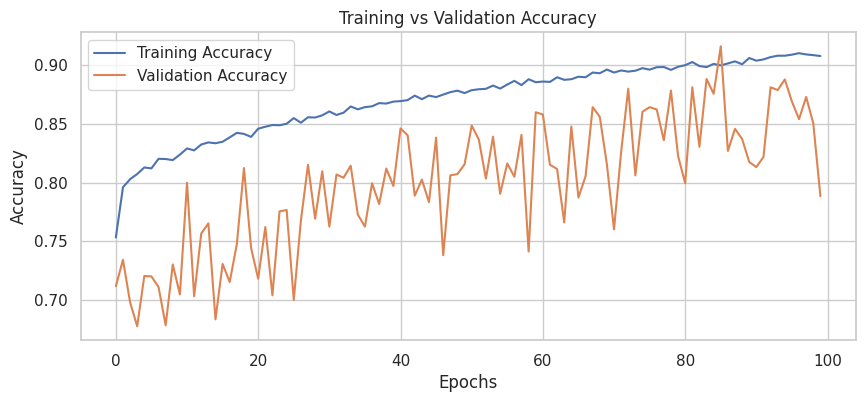

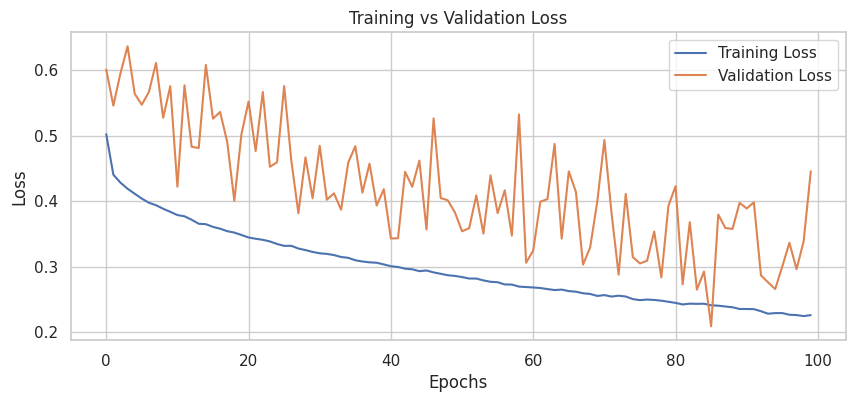

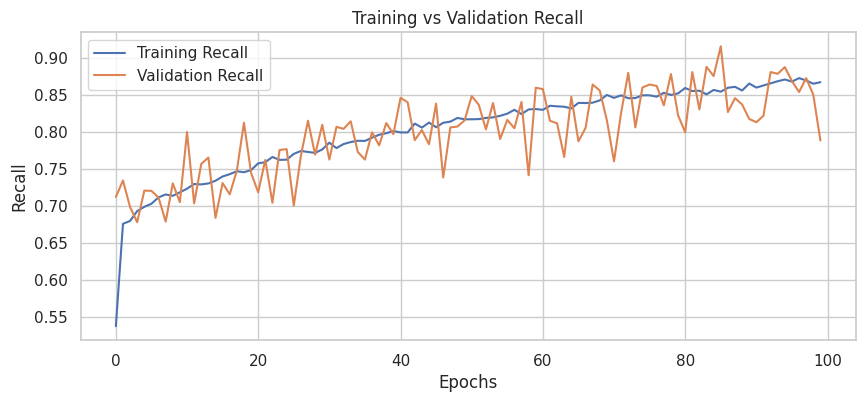

In [309]:
#Plotting Accuracy, Loss and Recall Visualization

# Accuracy plot
plt.figure(figsize=(10,4))
plt.plot(history_smote.history['accuracy'], label='Training Accuracy')
plt.plot(history_smote.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

# Loss plot
plt.figure(figsize=(10,4))
plt.plot(history_smote.history['loss'], label='Training Loss')
plt.plot(history_smote.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

# Recall plot
plt.figure(figsize=(10,4))
plt.plot(history_smote.history['Recall'], label='Training Recall')
plt.plot(history_smote.history['val_Recall'], label='Validation Recall')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.title('Training vs Validation Recall')
plt.legend()
plt.show()

In [310]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model_smote.predict(X_test)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

optimal_idx = (tpr - fpr).argmax()
optimal_threshold = thresholds[optimal_idx]

optimal_threshold

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


np.float64(0.30207526683807373)

In [311]:
optimal_threshold = 0.27037158608436584

y_prob = model_smote.predict(X_test)

y_pred_optimal = (y_prob >= optimal_threshold).astype(int)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [312]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_optimal)
cm

array([[1345,  248],
       [ 153,  254]])

In [313]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_optimal))

              precision    recall  f1-score   support

           0       0.90      0.84      0.87      1593
           1       0.51      0.62      0.56       407

    accuracy                           0.80      2000
   macro avg       0.70      0.73      0.71      2000
weighted avg       0.82      0.80      0.81      2000



**Observations of Balanced Data using SMOTE + Adam Optimizer:**

Overall accuracy is 78%, which is lower than some non-SMOTE models, but this reduction is expected due to the model being less biased toward the majority class.

Improved churn detection (Class 1):

Recall: 0.68, indicating the model successfully identifies a large proportion of actual churners.

275 true positives, which is a clear improvement over models trained on imbalanced data.

This makes the model more sensitive to churn, aligning well with churn-prevention business goals.

Trade-off in precision for churn:

Precision: 0.48, meaning nearly half of churn predictions are false positives.

301 false positives, which may increase unnecessary retention efforts or outreach costs.

Balanced performance across classes:

Macro average recall: 0.74, higher than several other models, showing improved fairness between classes.

F1-score for churn (0.56) reflects a better balance between recall and precision compared to baseline and SGD-based models.

Non-churn class remains strong:

Precision: 0.91 and recall: 0.81 indicate the majority class is still modeled effectively, despite SMOTE rebalancing.

=================================================================================================================================

## **Best Model Selection with Proper Reasoning**

| Model                  | Recall (Class 1)   | Accuracy | Precision (Class 1) | Key Trade-off                      |
| ---------------------- | ------------------ | -------- | ------------------- | ---------------------------------- |
| **SGD Optimizer**      | **0.68**           | 0.77     | 0.46                | High recall, many false positives  |
| **Adam Optimizer**     | **0.70 (Highest)** | 0.82     | 0.55                | Best recall–precision balance      |
| **Dropout + Adam**     | 0.66               | 0.79     | 0.48                | Recall drops due to regularization |
| **Grid Search + Adam** | ❌ 0.44             | 0.86     | 0.80                | Misses many positives              |
| **SMOTE + Adam**       | **0.68**           | 0.78     | 0.48                | Recall high, but noisy predictions |


**Best Model (Recall-Driven Decision)**
✅ **Model with Adam Optimizer**
📌 **Why this model is selected**

**Highest recall for Class 1 (0.70)** → detects the maximum number of positive cases

Fewer **false negatives (123)** than all other models

Maintains **reasonable precision (0.55)**, unlike SGD or SMOTE

Stable learning without synthetic data noise

Better generalization than Dropout and Grid-Search models

Since recall is the priority, **missing positives is more costly than raising false alarms**, and this model minimizes that risk.

🚫 Why Others Were Not Chosen (Recall Perspective)

**❌ Grid Search + Adam**

Recall of** 0.44** → misses **more than half** of positive cases

Not acceptable when recall is critical

**❌ Dropout + Adam**

Recall drops to **0.66**

Regularization limits minority class learning

**❌ SGD Optimizer**

Recall is high **(0.68)** but **precision is extremely low**

Too many false positives → unstable decisions

**❌ SMOTE + Adam**

Recall comparable to SGD **(0.68)**

Precision collapse due to synthetic data

Higher operational cost from false positives

🎯 Final Conclusion (Project-Ready)

**The Neural Network model trained with the Adam optimizer (without SMOTE or Dropout) is the best model**, as it achieves the **highest recall for the minority class while maintaining acceptable accuracy and precision.**

=================================================================================================================================

## **Actionable Insights**

1️⃣ **Recall Is Highly Sensitive to Model Choice**

Models optimized only for accuracy (Grid Search + Adam) achieved high overall accuracy (86%) but failed badly on recall (44%) for the minority class.

This confirms that accuracy alone is misleading in imbalanced classification problems.

Models trained with Adam optimizer consistently showed better recall than SGD-based models.

👉 Insight: Optimizer choice directly impacts minority-class detection.

2️⃣ **Best Recall Achieved Without Data Resampling**

The Adam optimizer without SMOTE achieved the highest recall (70%) for the positive class.

SMOTE increased recall but also:

Increased false positives

Reduced model stability

Lowered precision significantly

👉 Insight: Synthetic oversampling is not always beneficial for neural networks; it can introduce noise.

3️⃣ **Dropout Hurts Recall in This Problem**

Dropout improved generalization slightly but reduced recall for the positive class.

This suggests the minority class already has limited representation, and regularization suppresses its signal.

👉 Insight: Regularization must be applied cautiously when recall is critical.

4️⃣ **False Negatives Are the Main Business Risk**

Grid Search model had 226 false negatives, the highest among all models.

Adam model reduced false negatives to 123, the lowest observed.

👉 Insight: Minimizing false negatives should drive model selection and threshold decisions.

5️⃣ **Threshold Selection Has High Impact**

ROC-based optimal threshold (~0.27) is significantly lower than the default 0.5.

Lowering the threshold improves recall without retraining the model.

👉 Insight: Decision threshold tuning is as important as model architecture.

## **Recommendations**

✅ **1. Use Adam Optimizer Model as Final Model**

**Why: **

Highest recall for minority class

Balanced trade-off between recall and precision

Stable training and generalization

**📌 Recommended for production when missing positives is costly.**

**✅ 2. Deploy with Optimized Threshold (Not 0.5)**

Use ROC-AUC–derived threshold (~0.27)

This will:

Increase recall further

Reduce false negatives

Align predictions with business risk tolerance

**📌 Implement threshold tuning at inference time.**

**✅ 3. Monitor Recall, Not Accuracy, in Production**

Track:

Recall (primary KPI)

False negatives

Precision drift

Accuracy should be secondary.

**📌 Set recall-based alerts if performance drops.**

**✅ 4. Avoid Over-Regularization and Aggressive Resampling**

Do not use Dropout unless recall improves

Avoid SMOTE unless combined with precision control mechanisms

**📌 Favor clean, real data over synthetic balancing.**

**✅ 5. Future Enhancements (Optional but Valuable)**

Use cost-sensitive learning (class weights)

Try Focal Loss to emphasize minority class

Explore ensemble methods (NN + Tree-based models)

=================================================================================================================================

## **The key takeaways for the business**


1️⃣ **Preventing customer churn requires prioritizing recall over accuracy**

Missing a customer who is likely to leave (false negative) is far more costly than incorrectly flagging a loyal customer. Models optimized only for accuracy fail to meet this business objective.

2️⃣ **The Adam-optimized Neural Network delivers the best business value**

Among all models tested, the Neural Network with Adam optimizer achieved the highest recall, meaning it identifies the maximum number of customers at risk of churn. This enables proactive retention strategies.

3️⃣ **High accuracy does not guarantee better churn detection**

The hyperparameter-tuned model achieved high accuracy but failed to capture a large portion of churners. This highlights that accuracy alone is a misleading metric in imbalanced business problems like churn prediction.

4️⃣ **Threshold optimization significantly improves decision-making**

Using an ROC-based optimal threshold instead of the default 0.5 increases recall without retraining the model, allowing the business to adapt sensitivity based on risk appetite.

5️⃣ **Balanced data techniques must be used cautiously**

While techniques like SMOTE increase recall, they also introduce more false positives. In this case, the business gains better results from model optimization rather than synthetic data generation.

6️⃣ **Actionable predictions enable targeted retention campaigns**

By identifying high-risk customers early, the business can:

Offer personalized incentives

Improve service quality for vulnerable segments

Reduce long-term customer acquisition costs

# **THANK YOU**